# Retail Sales Performance Analysis Using Python, SQL, and Power BI

## A. Data Understanding

### Dataset overview

In [60]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/retail_sales_dataset.csv")

# Overview
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [62]:
df.describe(include="all")

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST001,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
std,288.819436,NaN,NaN,NaN,13.68143,NaN,1.132734,189.681356,559.997632
min,1.000000,NaN,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,NaN,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,NaN,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,NaN,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000


**1. Understanding the columns:**
- Transaction ID: Unique identifier for each sale.

- Date: When the transaction occurred.

- Customer ID: Unique identifier for each customer.

- Gender & Age: Customer demographics, useful for segment analysis.

- Product Category: Type of product sold (Beauty, Clothing, Electronics).

- Quantity: Number of units sold in the transaction.

- Price per Unit: Selling price of a single unit.

- Total Amount: Total revenue from the transaction (Quantity × Price per Unit).

**2. Time range:**

- Dates are in 2023 (from Jan to Nov, based on top values).

**3. Dataset size:**

- 1,000 transactions, 3 product categories, 2 gender categories.

**4. Quick observations:**

- Total Amount is correctly calculated as Quantity × Price per Unit.

- No missing values across any columns.

- Quantity ranges from 1–4, Price per Unit varies widely (25–500), and Total Amount ranges 25–2000, which is realistic for retail.

## B. Data Cleaning

The goal here is not to make the data “pretty.”
The goal is to make it trustworthy for business decisions.

### 1. Date conversion

In [63]:
df["Date"] = pd.to_datetime(df["Date"])

Converted the Date column from string/object format to a proper datetime type.

Time-based analysis (monthly trends, growth rates, seasonality) is impossible or error-prone without correct date typing

### 2. Duplicate check

In [64]:
df.duplicated().sum()

0

Checked for duplicate rows.

Duplicate records found: **0**

Each transaction is uniquely identified by Transaction ID, and no repeated records were observed.

### 3. Standardizing categorical values

In [65]:
# Standardize Product Category names
df["Product Category"] = df["Product Category"].str.strip().str.title()

Standardized Product Category formatting using trimming and title casing.

Inconsistent labels (e.g., `clothing`, `Clothing` , `CLOTHING`) fragment analysis and inflate category counts artificially. Standardization ensures accurate aggregation and reporting.

### 4. Revenue validation

In [66]:
# Validate Total Amount calculation
df["Calculated Total"] = df["Quantity"] * df["Price per Unit"]
mismatch_count = (df["Total Amount"] != df["Calculated Total"]).sum()
mismatch_count

0

Recomputed Total Amount.

Found 0 mismatches.

In [67]:
df = df.drop(columns="Calculated Total", axis=1)

Revenue is the backbone of this analysis. Verifying derived fields protects against upstream data-entry or ETL errors and increases confidence in downstream insights.

## C. Exploratory Data Analysis (EDA)

### 1. Total Sales Over Time (Line Chart)

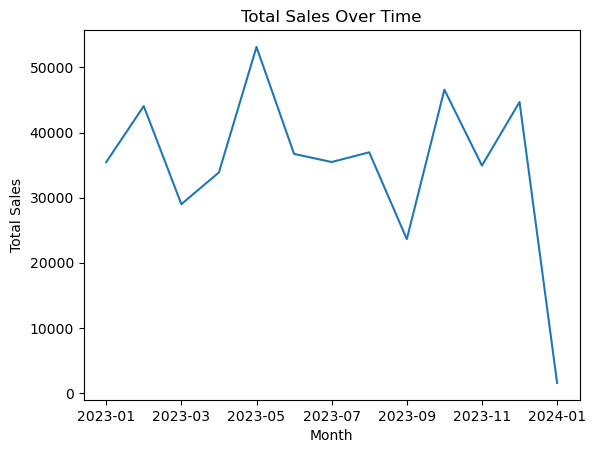

In [68]:
import matplotlib.pyplot as plt

# Create helper columns
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# Total sales over time
sales_over_time = df.groupby("Month")["Total Amount"].sum()

plt.figure()
sales_over_time.plot()
plt.title("Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

We observe that:
- Sales fluctuate across the year rather than growing steadily.
- There are noticeable peaks around **May, October, and December**, suggesting seasonal demand or promotional periods.
- The sharp drop at the end likely reflects **partial-month data**, not a true collapse in sales.

Sales performance is seasonal. Planning inventory, staffing, and promotions should be aligned with high-demand months rather than assuming uniform demand.

### 2. Total Sales by Product Category (Bar Chart)

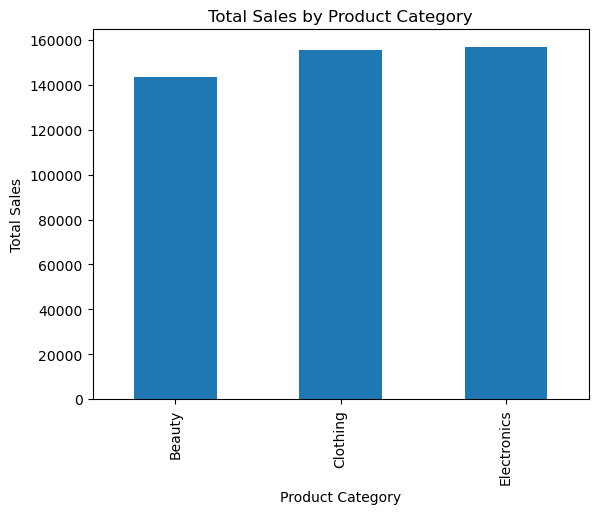

In [69]:
sales_by_category = df.groupby("Product Category")["Total Amount"].sum()

plt.figure()
sales_by_category.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

**Electronics and Clothing** generate the highest total revenue. Beauty contributes meaningfully but lags behind the other two categories.

Revenue is concentrated in a small number of categories. Product prioritization and marketing spend should focus on Electronics and Clothing while investigating growth opportunities or margin improvements in Beauty.

### 3. Quantity vs Total Sales Amount (Scatter Plot)

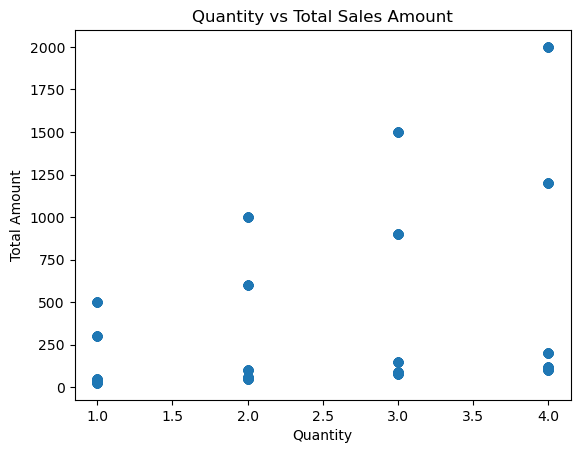

In [70]:
# Sales behavior
plt.figure()
plt.scatter(df["Quantity"], df["Total Amount"])
plt.title("Quantity vs Total Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

We observe that:
- Higher quantities do not always lead to proportionally higher revenue.
- Transactions with small quantities can still generate high sales when unit prices are high.
- Revenue is driven more by product pricing than by sheer volume.

Pushing volume alone is not a reliable growth strategy. Pricing, product mix, and upselling higher-value items have a stronger impact on revenue.

### 4. Total Sales by Customer Gender (Bar Chart)

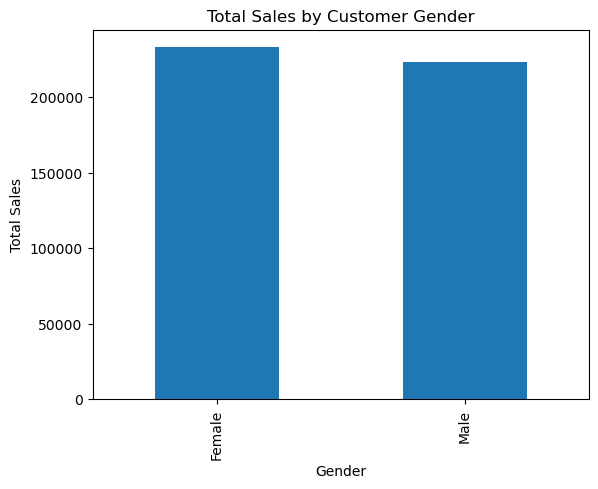

In [71]:
# Sales by Gender (Customer Segment proxy)
sales_by_gender = df.groupby("Gender")["Total Amount"].sum()

plt.figure()
sales_by_gender.plot(kind='bar')
plt.title("Total Sales by Customer Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.show()

Sales contributions from **Male and Female customers are relatively balanced**, with no extreme dominance. Neither segment overwhelmingly outperforms the other.

Gender-based targeting alone is unlikely to unlock major revenue gains. More granular segmentation (behavioral, category preference, order value) would be more effective.

### 5. Average Order Value (AOV) by Product Category (Bar Chart)

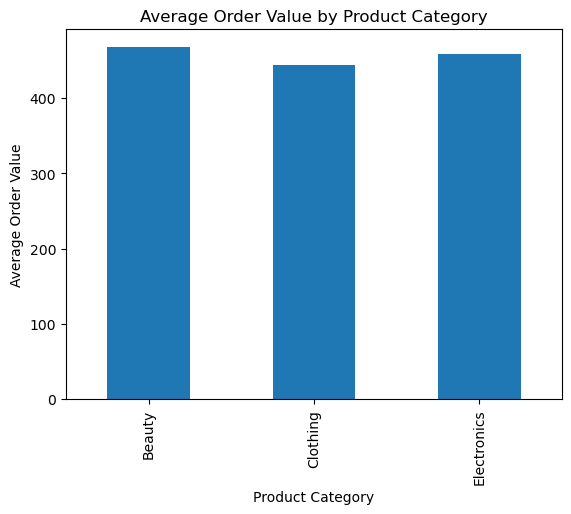

In [72]:
aov_by_category = df.groupby("Product Category")["Total Amount"].mean()

plt.figure()
aov_by_category.plot(kind='bar')
plt.title("Average Order Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Order Value")
plt.show()

**Beauty** and **Electronics** show higher average order values compared to Clothing.

Clothing generates strong total revenue largely through transaction volume, not order size.

Different categories win in different ways:
- Clothing = volume-driven revenue
- Electronics & Beauty = value-driven revenue

Strategies should reflect this distinction rather than applying one-size-fits-all tactics.

Next step is SQL analysis

In [73]:
df=df.drop(columns="Month")

### Renaming the columns to be SQL friendly

In [74]:
df = df.rename(columns = {
    "Transaction ID": "transaction_id", 
    "Date": "date", 
    "Customer ID": "customer_id", 
    "Gender": "gender",
    "Age": "age", 
    "Product Category": "product_category", 
    "Quantity": "quantity", 
    "Price per Unit": "price_per_unit",
    "Total Amount": "total_amount"
})

In [75]:
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')

### Saving the cleaned dataset

In [76]:
df.to_csv('data/cleaned_retail_dataset.csv', index=False)

## D. SQL Analysis

### 1. Top revenue-generating product categories

This query answers:
Which categories drive the majority of revenue?

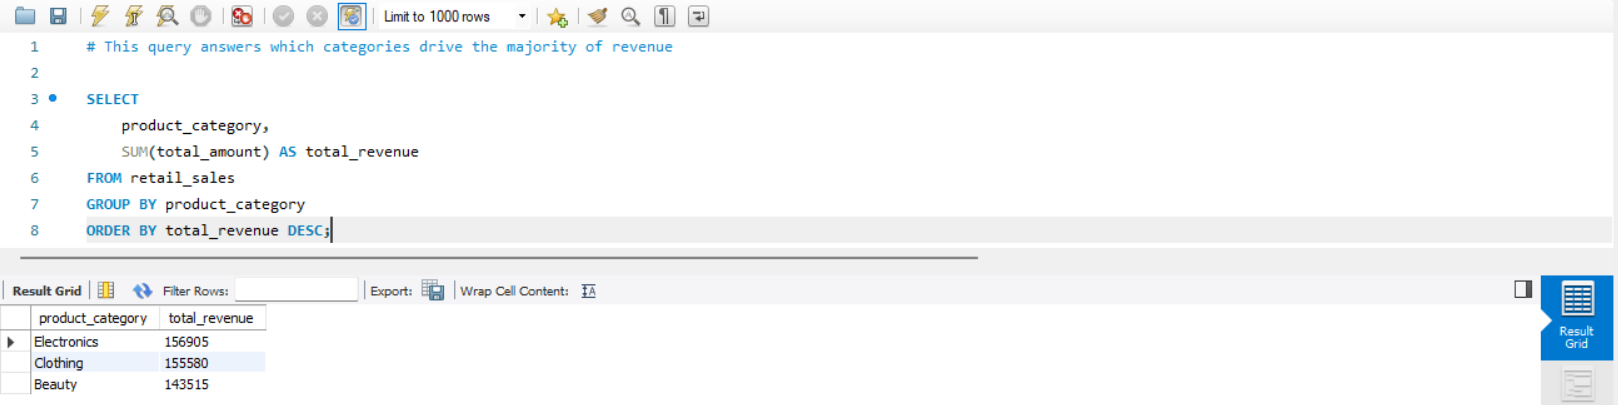

No single category overwhelmingly dominates revenue. The business is not overly dependent on one product line, which reduces concentration risk but also means growth likely requires incremental improvements across multiple categories.

### 2. Monthly sales trend

How does revenue change over time?

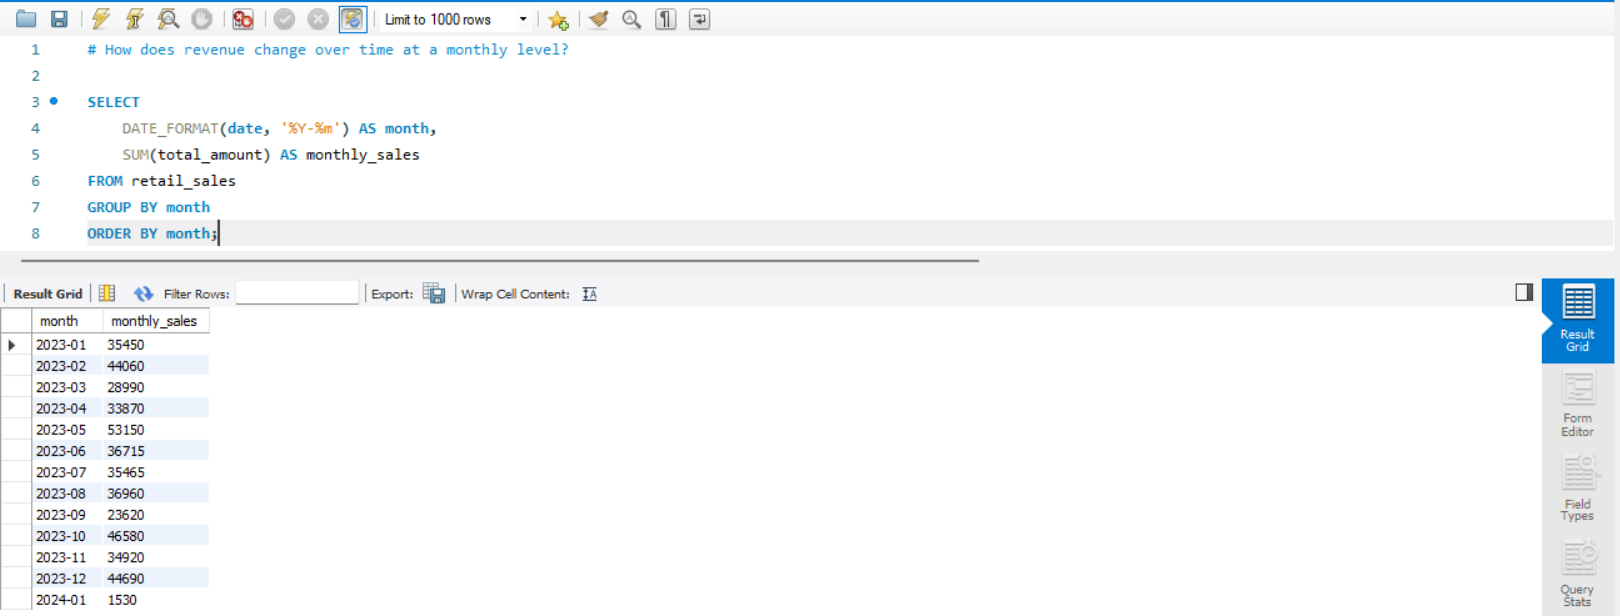

Sales fluctuate significantly month-to-month rather than following a smooth upward trend.

May (₦53,150) and October $₦46,580) are the strongest months, suggesting seasonal demand or promotional activity.

September (₦23,620) and March (₦28,990) are notably weaker.

January 2024 (₦1,530) is an outlier and likely represents partial or incomplete data rather than a true collapse in sales.

Sales are seasonal rather than linear. Forecasting, inventory planning, and marketing spend should be aligned with historically strong months instead of assuming steady growth throughout the year.

### 3. High-volume, low-revenue transactions

This query answers:

Are we selling many units without making much money?

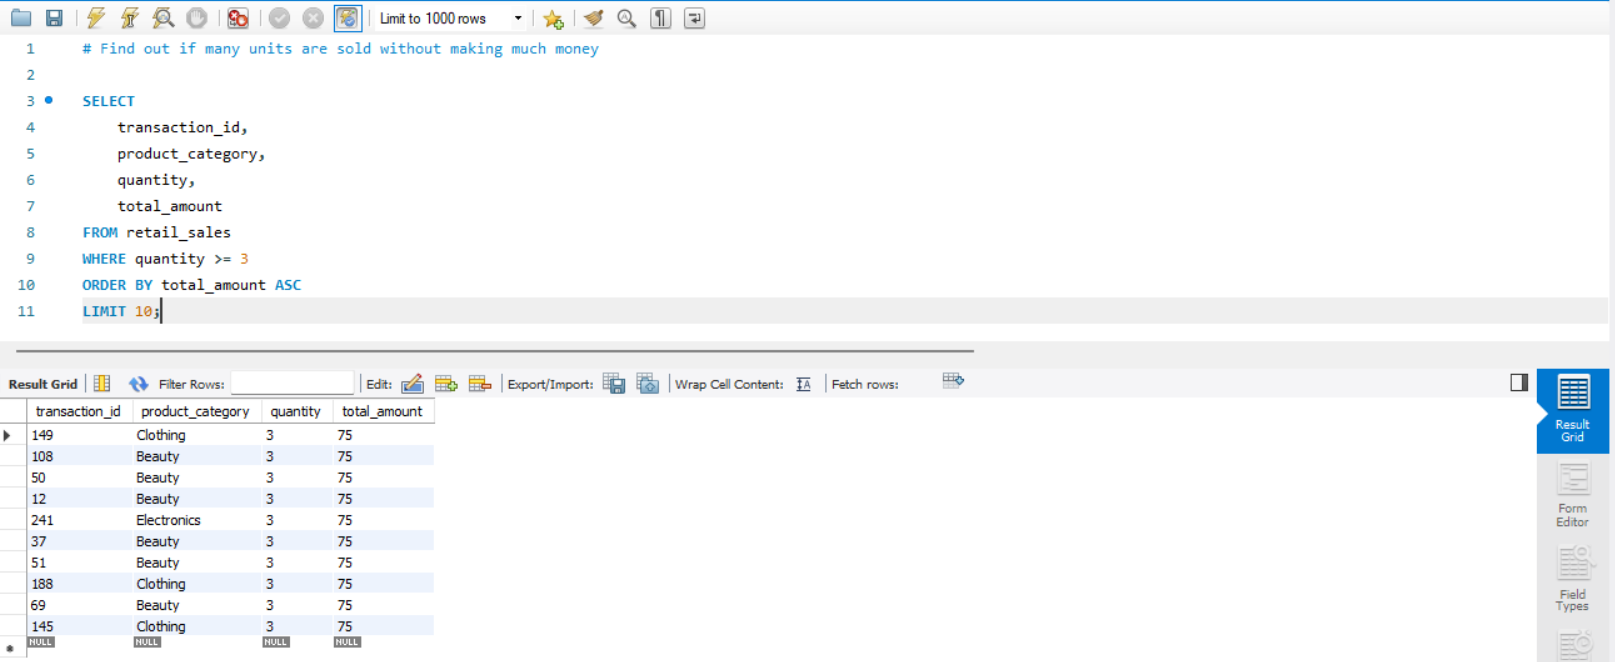

Multiple transactions involve selling 3 units for a total of only ₦75, across all product categories.

This pattern appears repeatedly and is not isolated to a single category.

These transactions strongly suggest very low unit prices or aggressive discounting. High volume alone is not translating into meaningful revenue, indicating potential margin leakage or pricing inefficiencies.

### 4. Average Order Value (AOV) by customer segment

Let's find out if different customer segments spend differently per transaction

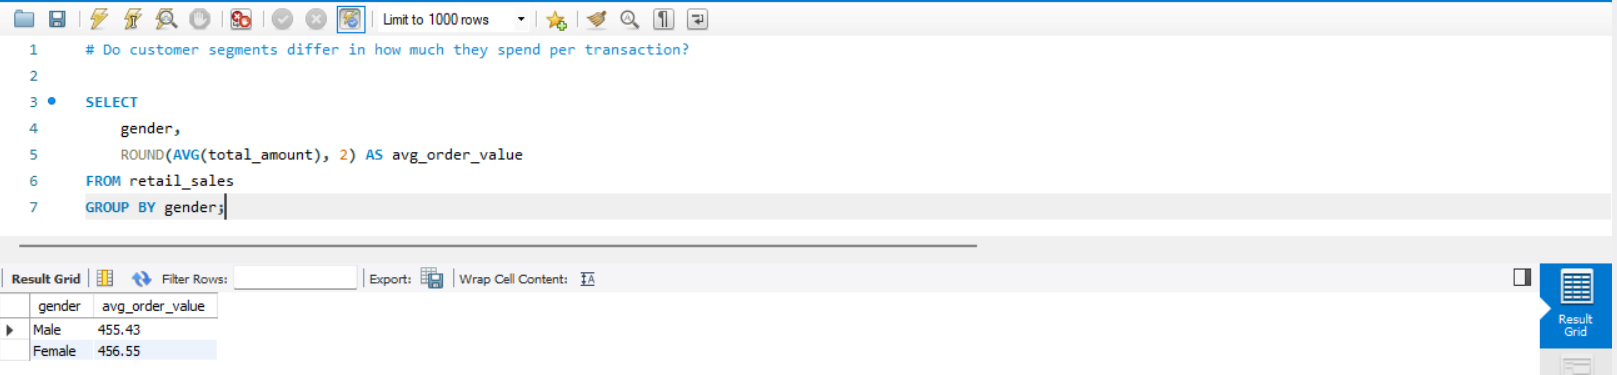

Average order value is almost identical across genders:
- Male: \$455.43
- Female: $456.55

There is no meaningful difference in spending behavior between male and female customers. Gender-based targeting or pricing strategies are unlikely to produce significant gains on their own.

This suggests the business should focus more on behavioral or product-based segmentation rather than demographic assumptions.

### 5. Revenue concentration

This query answers:

Is revenue concentrated in a small number of categories?

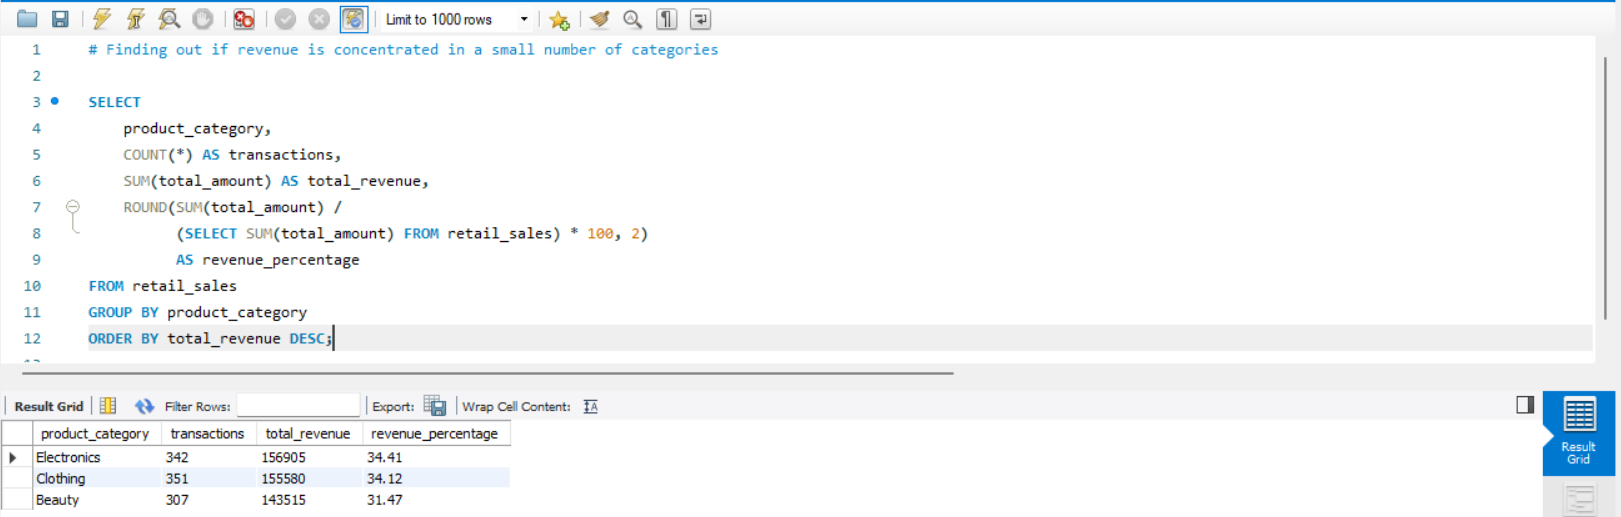

Revenue is not heavily concentrated in a single category. While this reduces dependency risk, it also means underperformance in any one category can materially affect overall revenue.

Growth strategies should therefore be category-wide, not category-exclusive.

### 6. Customer age vs spending

Do older or younger customers spend more per transaction?

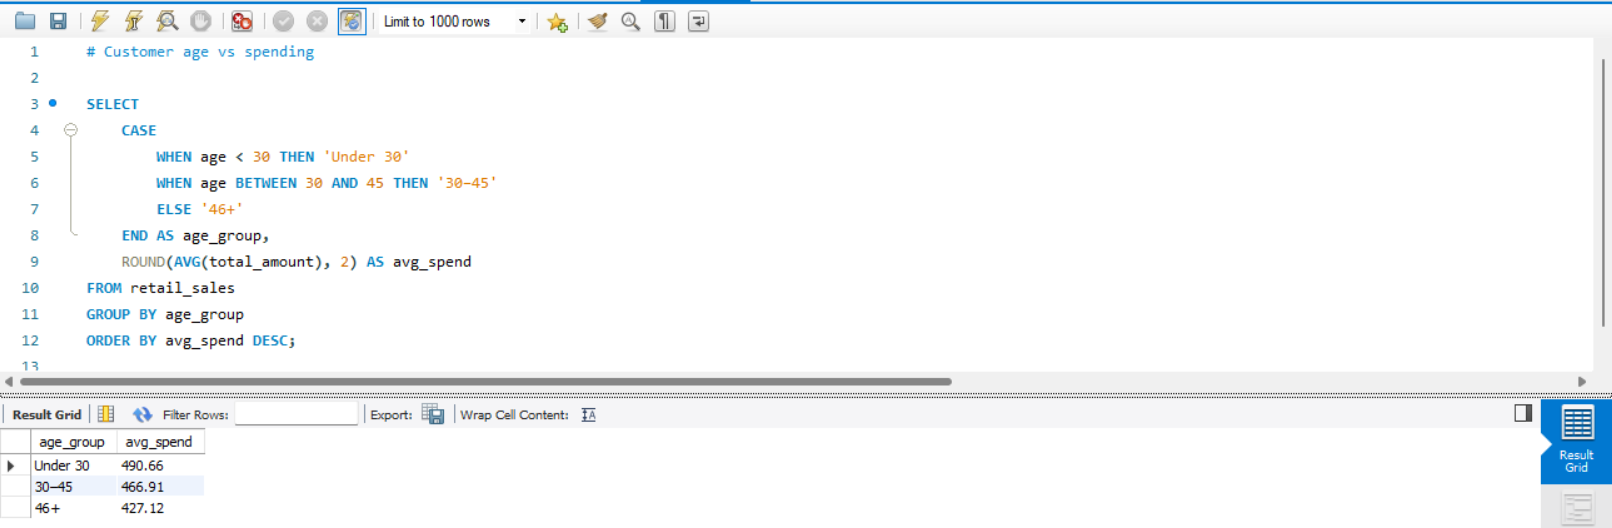

Younger customers tend to spend more per transaction. This may reflect greater engagement with higher-priced products, impulse purchases, or product categories such as electronics.

This insight supports prioritizing younger customer cohorts for premium products, bundles, or upsell strategies.

### 7. SQL Analysis Conclusion

Revenue is evenly distributed across product categories, indicating a diversified sales base but limited reliance on a single revenue engine. Sales performance is seasonal, with pronounced peaks in May and October, suggesting opportunities for targeted promotions and inventory optimization. Several high-volume, low-revenue transactions point to potential pricing inefficiencies. Customer gender shows no meaningful impact on order value, while younger customers consistently exhibit higher average spend.

## E. Power BI Dashboard

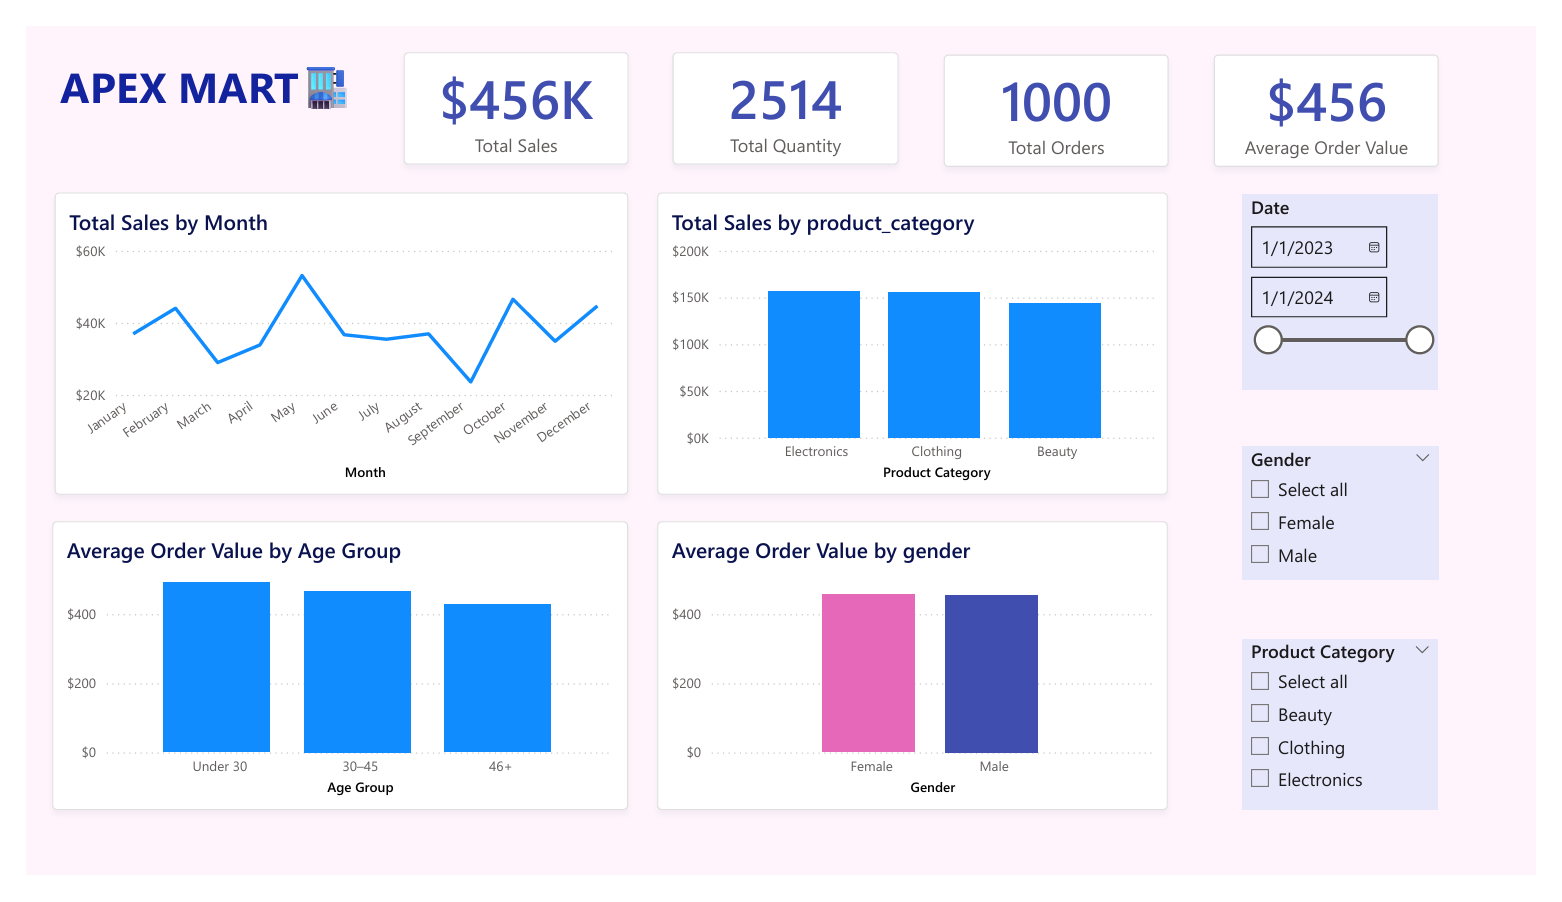

#### **Insights**

- Revenue is evenly distributed across product categories, indicating a diversified sales base with no single point of failure.

- Sales performance is seasonal, with peaks in May and October, suggesting opportunities for targeted promotions and inventory planning.

- Several high-volume, low-revenue transactions point to potential pricing inefficiencies.

- Customer gender shows minimal impact on order value, while younger customers consistently demonstrate higher average spend.

### Business Impact

>This analysis supports data-driven decisions around product prioritization, pricing optimization, regional strategy, and customer targeting.